<a href="https://colab.research.google.com/github/ShankarReddy70/Deep-Learning/blob/master/DL_task-01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 31s 32ms/step - accuracy: 0.8668 - loss: 0.4375 - val_accuracy: 0.9818 - val_loss: 0.0572
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 33ms/step - accuracy: 0.9838 - loss: 0.0528 - val_accuracy: 0.9877 - val_loss: 0.0399
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - accuracy: 0.9883 - loss: 0.0371 - val_accuracy: 0.9847 - val_loss: 0.0494
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 31ms/step - accuracy: 0.9921 - loss: 0.0252 - val_accuracy: 0.9845 - val_loss: 0.0456
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 32ms/step - accuracy: 0.9935 - loss: 0.0213 - val_accuracy: 0.9904 - val_loss: 0.0336
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9875 - loss: 0.0439
Test accuracy: 0.9904000163078308


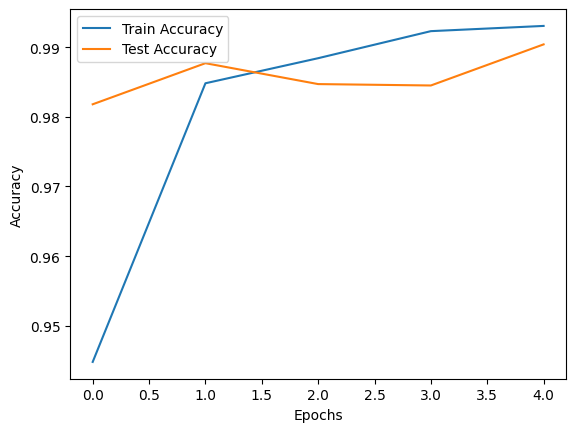

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Step 1: Load and preprocess the dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize the images (pixel values between 0 and 1)
x_train, x_test = x_train / 255.0, x_test / 255.0

# Reshape images to add a channel dimension (grayscale)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Step 2: Build the CNN model
model = models.Sequential()

# Convolutional layers
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# Fully connected layer
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))

# Output layer (10 classes for MNIST)
model.add(layers.Dense(10, activation='softmax'))

# Step 3: Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Step 4: Train the model
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_data=(x_test, y_test))

# Step 5: Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'Test accuracy: {test_acc}')

# Plot training history (optional)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
